# Code for the transfomer, autoencoder and reinforcement learning model

Using device: cpu
Loading perovskite dataset...
Dataset loaded successfully with 11858 rows.

Exploring dataset...
Dataset shape: (11858, 399)

PCE Statistics:
count    11858.000000
mean        12.354820
std          5.140231
min          0.000000
25%          8.992500
50%         13.200000
75%         16.370000
max         24.660000
Name: JV_default_PCE, dtype: float64

Preprocessing data...
Starting data preprocessing...
Number of samples with valid target (JV_default_PCE): 11858
Sampled 5929 rows for faster training
Selected features: ['Perovskite_composition_a_ions', 'Perovskite_composition_a_ions_coefficients', 'Perovskite_composition_b_ions', 'Perovskite_composition_b_ions_coefficients', 'Perovskite_composition_c_ions', 'Perovskite_composition_c_ions_coefficients', 'Perovskite_composition_inorganic', 'Perovskite_composition_leadfree', 'Perovskite_dimension_3D', 'Perovskite_additives_compounds', 'Cell_architecture', 'ETL_stack_sequence', 'HTL_stack_sequence', 'Backcontact_stack_se

100%|██████████| 50/50 [00:00<00:00, 2114.73it/s]

Iteration 4: New best PCE = 17.1652
Iteration 12: New best PCE = 17.1660
Iteration 34: New best PCE = 17.1663
Optimization complete!
Best PCE achieved: 17.1663


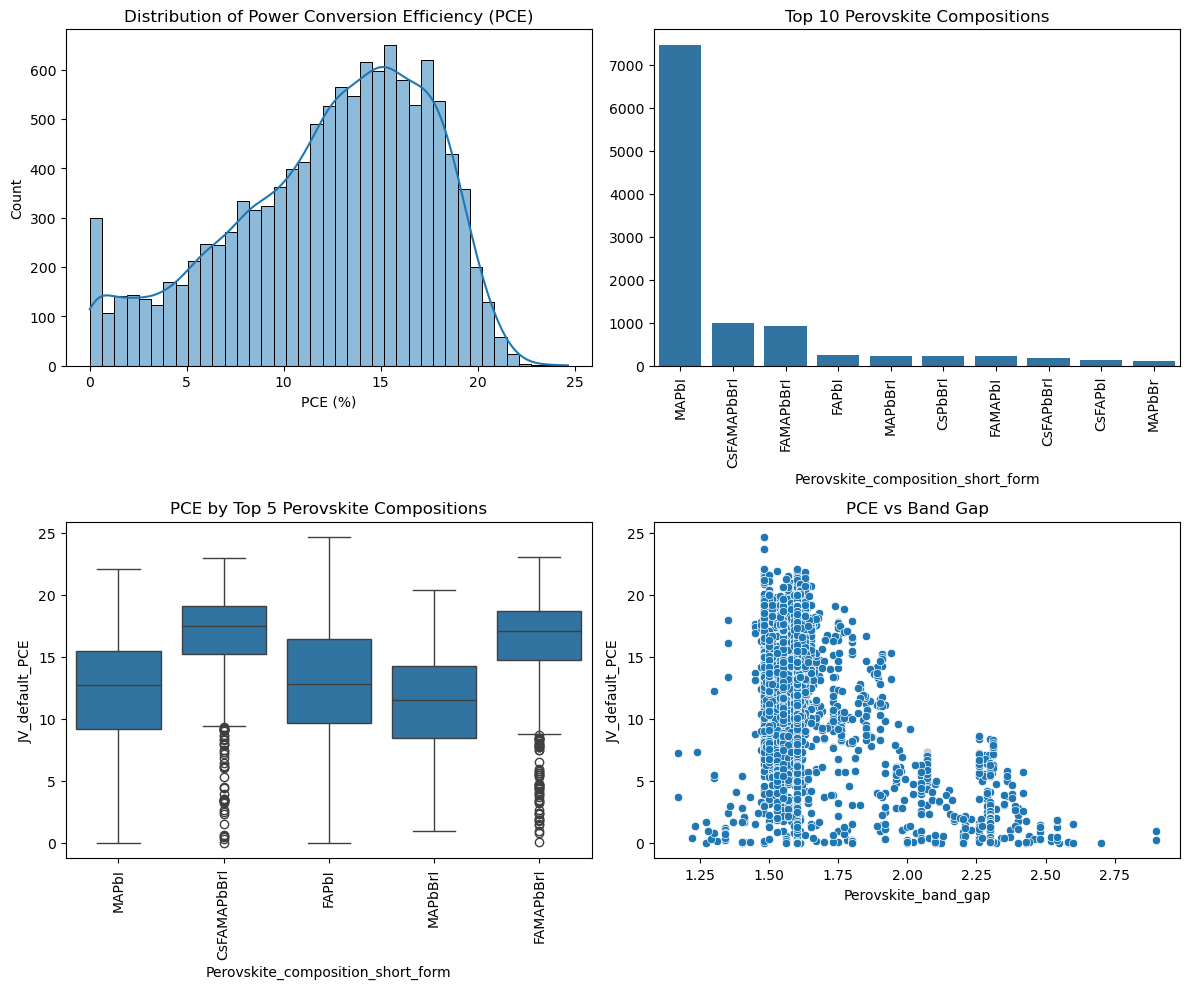

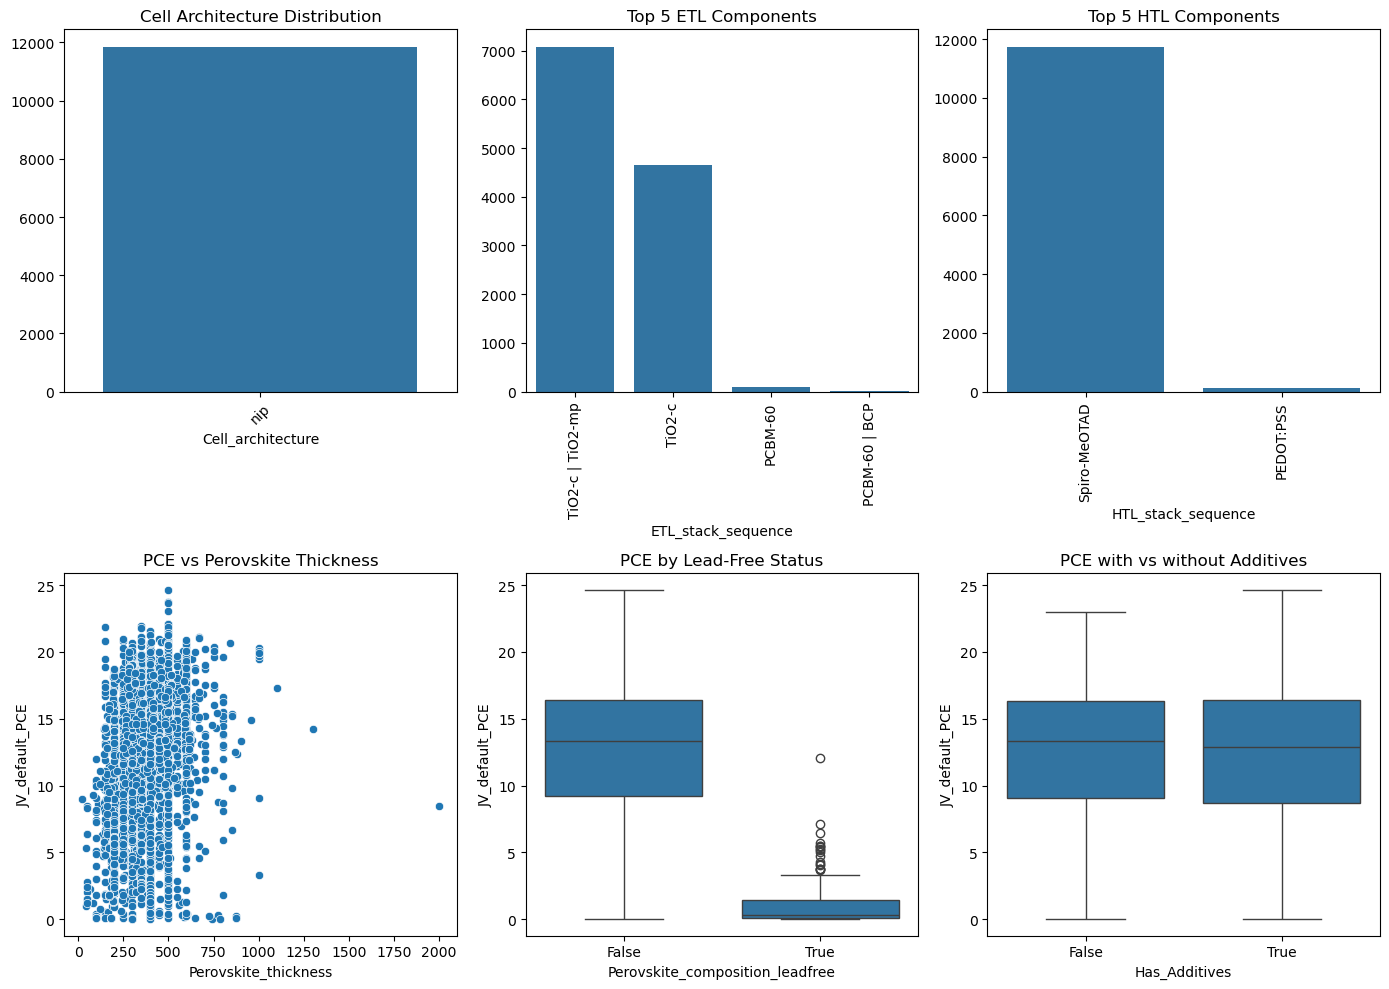

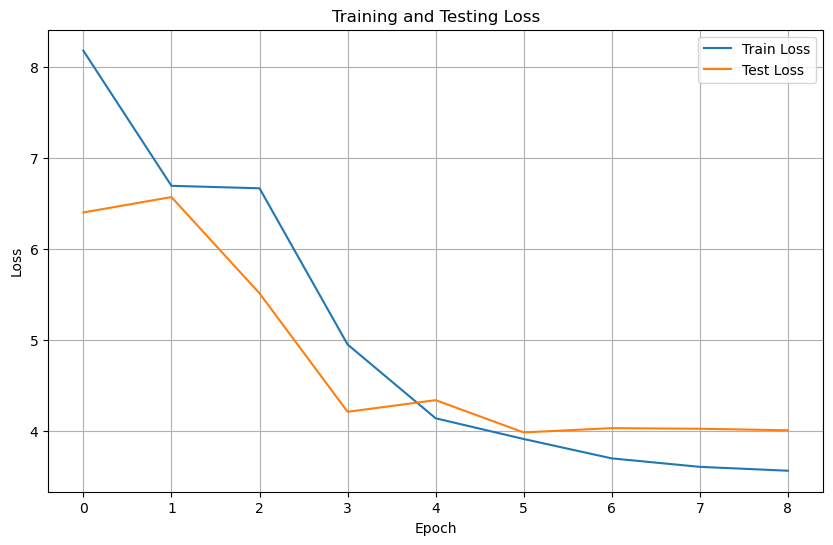

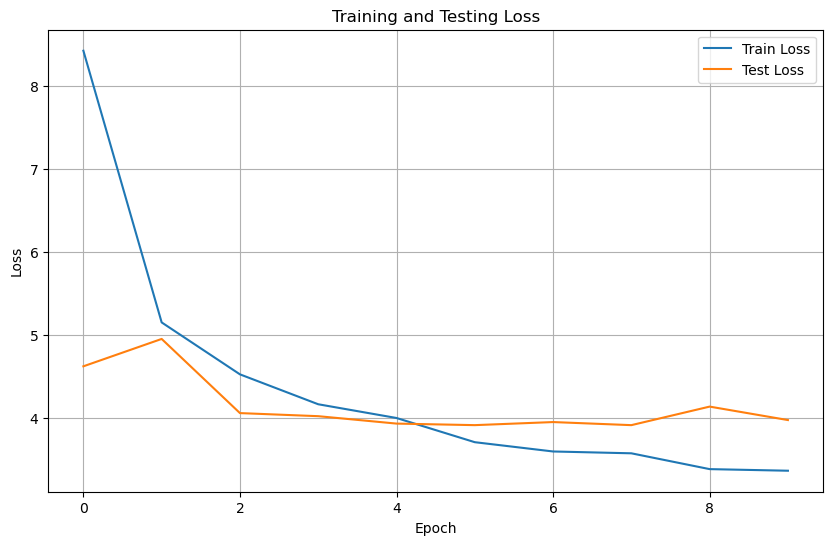

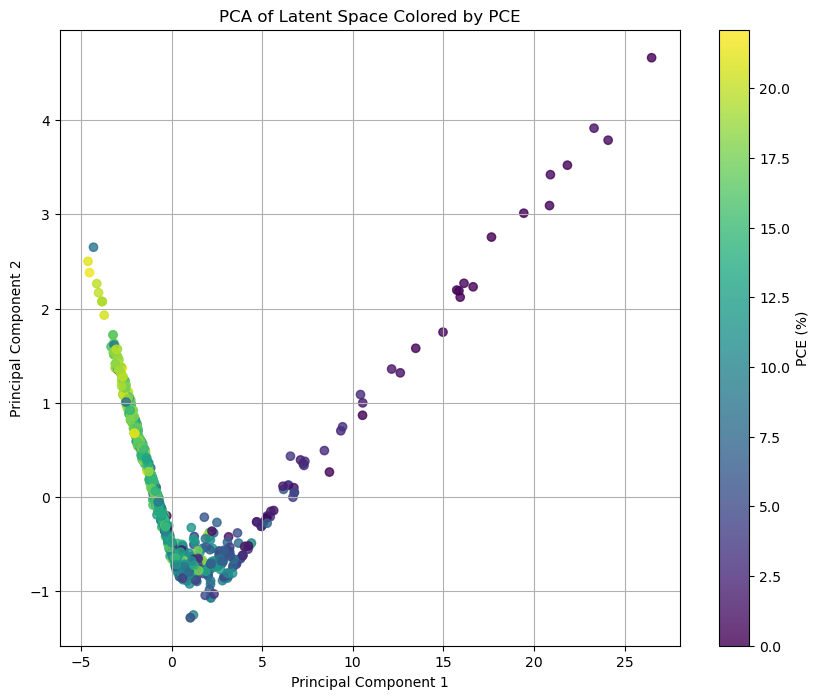

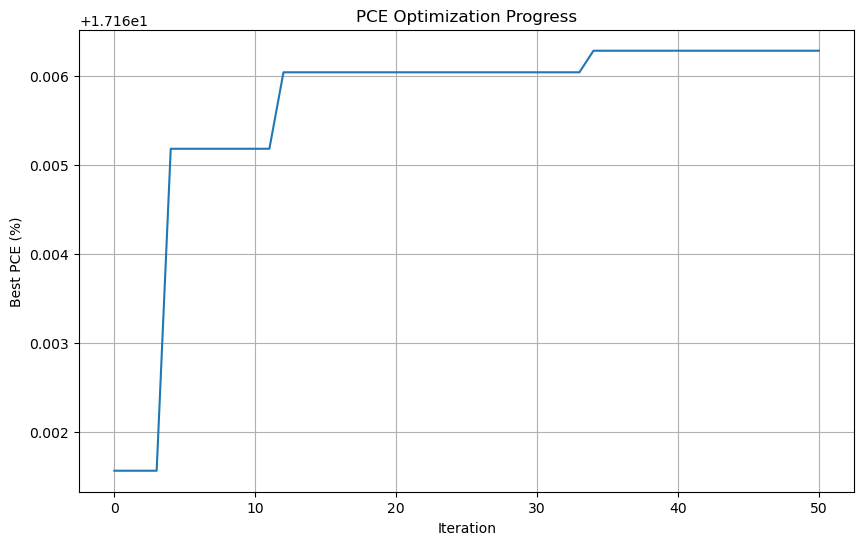


Best configuration interpretation:
Best PCE: 17.1663

Top features of best configuration:
Perovskite_thickness: 396.9577923290899
Perovskite_deposition_thermal_annealing_temperature: 100.0
Perovskite_deposition_thermal_annealing_time: 60.0
Perovskite_composition_c_ions_coefficients: 3
Perovskite_band_gap: 1.6411245908525154
Perovskite_composition_a_ions_coefficients: 1
Perovskite_composition_b_ions_coefficients: 1
Perovskite_dimension_3D: 0.9308522941866014
Perovskite_composition_inorganic: 0.07073338021795245
Perovskite_composition_leadfree: 0.04451879945920508

Predicted PCE: 17.1663%


<Figure size 1200x800 with 0 Axes>

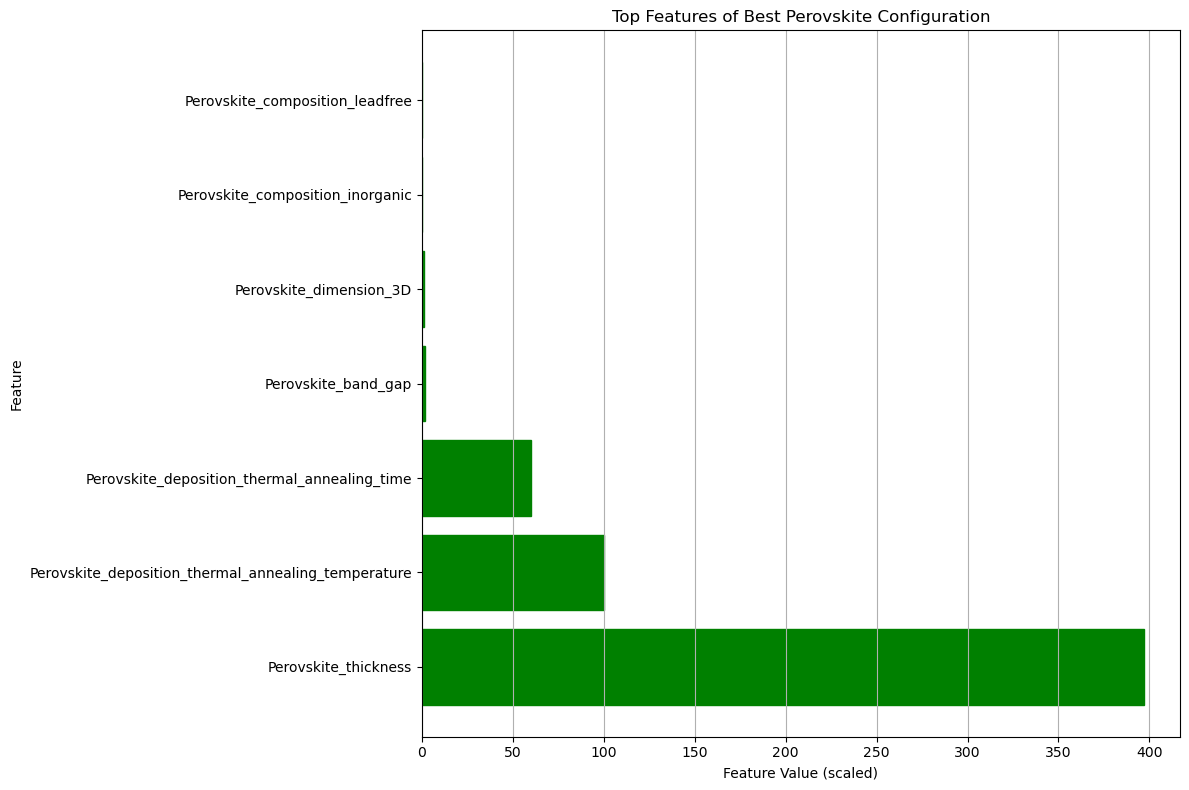

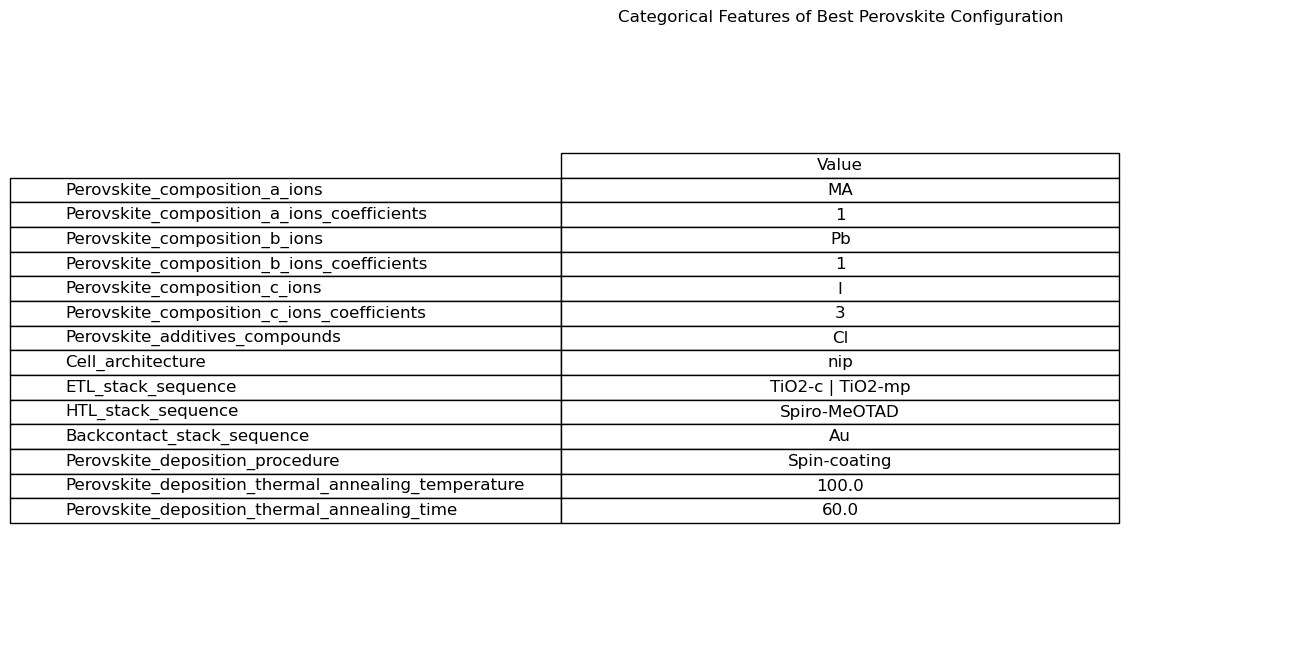

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Set up device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Data Exploration and Visualization
def explore_perovskite_data(df):
    """Explore and visualize the perovskite solar cell dataset"""
    print(f"Dataset shape: {df.shape}")
    
    # Create PCE distribution plot
    plt.figure(figsize=(12, 10))
    
    plt.subplot(2, 2, 1)
    sns.histplot(df['JV_default_PCE'].dropna(), kde=True)
    plt.title('Distribution of Power Conversion Efficiency (PCE)')
    plt.xlabel('PCE (%)')
    plt.ylabel('Count')
    
    # Perovskite composition analysis
    plt.subplot(2, 2, 2)
    composition_counts = df['Perovskite_composition_short_form'].value_counts().head(10)
    sns.barplot(x=composition_counts.index, y=composition_counts.values)
    plt.title('Top 10 Perovskite Compositions')
    plt.xticks(rotation=90)
    
    # PCE by composition
    plt.subplot(2, 2, 3)
    top_compositions = df['Perovskite_composition_short_form'].value_counts().head(5).index
    composition_pce = df[df['Perovskite_composition_short_form'].isin(top_compositions)]
    sns.boxplot(x='Perovskite_composition_short_form', y='JV_default_PCE', data=composition_pce)
    plt.title('PCE by Top 5 Perovskite Compositions')
    plt.xticks(rotation=90)
    
    # PCE vs band gap (if available)
    plt.subplot(2, 2, 4)
    if 'Perovskite_band_gap' in df.columns:
        valid_data = df[['Perovskite_band_gap', 'JV_default_PCE']].dropna()
        sns.scatterplot(x='Perovskite_band_gap', y='JV_default_PCE', data=valid_data)
        plt.title('PCE vs Band Gap')
    
    plt.tight_layout()
    plt.savefig('pce_distributions.png')
    
    # Additional visualizations for cell architecture and components
    plt.figure(figsize=(14, 10))
    
    # Cell architecture distribution
    plt.subplot(2, 3, 1)
    arch_counts = df['Cell_architecture'].value_counts()
    sns.barplot(x=arch_counts.index, y=arch_counts.values)
    plt.title('Cell Architecture Distribution')
    plt.xticks(rotation=45)
    
    # ETL components (if available)
    plt.subplot(2, 3, 2)
    if 'ETL_stack_sequence' in df.columns:
        etl_counts = df['ETL_stack_sequence'].value_counts().head(5)
        sns.barplot(x=etl_counts.index, y=etl_counts.values)
        plt.title('Top 5 ETL Components')
        plt.xticks(rotation=90)
    
    # HTL components (if available)
    plt.subplot(2, 3, 3)
    if 'HTL_stack_sequence' in df.columns:
        htl_counts = df['HTL_stack_sequence'].value_counts().head(5)
        sns.barplot(x=htl_counts.index, y=htl_counts.values)
        plt.title('Top 5 HTL Components')
        plt.xticks(rotation=90)
    
    # Perovskite thickness vs PCE (if available)
    plt.subplot(2, 3, 4)
    if 'Perovskite_thickness' in df.columns:
        valid_thickness = df[['Perovskite_thickness', 'JV_default_PCE']].dropna()
        sns.scatterplot(x='Perovskite_thickness', y='JV_default_PCE', data=valid_thickness)
        plt.title('PCE vs Perovskite Thickness')
    
    # PCE by lead-free status (if available)
    plt.subplot(2, 3, 5)
    if 'Perovskite_composition_leadfree' in df.columns:
        lead_status = df.dropna(subset=['Perovskite_composition_leadfree', 'JV_default_PCE'])
        sns.boxplot(x='Perovskite_composition_leadfree', y='JV_default_PCE', data=lead_status)
        plt.title('PCE by Lead-Free Status')
    
    # Perovskite additive analysis
    plt.subplot(2, 3, 6)
    if 'Perovskite_additives_compounds' in df.columns:
        # Check if additives present or not
        df['Has_Additives'] = df['Perovskite_additives_compounds'].notna()
        additives_pce = df.dropna(subset=['JV_default_PCE'])
        sns.boxplot(x='Has_Additives', y='JV_default_PCE', data=additives_pce)
        plt.title('PCE with vs without Additives')
    
    plt.tight_layout()
    plt.savefig('cell_components.png')
    
    # Return descriptive statistics for PCE
    return df['JV_default_PCE'].describe()

def visualize_perovskite_structure(df):
    """Create specialized visualizations of the perovskite composition space"""
    plt.figure(figsize=(15, 10))
    
    # 1. Analyze A-site cations
    plt.subplot(2, 3, 1)
    a_ions = df['Perovskite_composition_a_ions'].dropna().str.split(';').explode()
    a_counts = a_ions.value_counts().head(10)
    sns.barplot(x=a_counts.index, y=a_counts.values)
    plt.title('Top A-site Cations')
    plt.xticks(rotation=45)
    
    # 2. Analyze B-site cations
    plt.subplot(2, 3, 2)
    b_ions = df['Perovskite_composition_b_ions'].dropna().str.split(';').explode()
    b_counts = b_ions.value_counts().head(10)
    sns.barplot(x=b_counts.index, y=b_counts.values)
    plt.title('Top B-site Cations')
    plt.xticks(rotation=45)
    
    # 3. Analyze X-site anions
    plt.subplot(2, 3, 3)
    c_ions = df['Perovskite_composition_c_ions'].dropna().str.split(';').explode()
    c_counts = c_ions.value_counts().head(10)
    sns.barplot(x=c_counts.index, y=c_counts.values)
    plt.title('Top X-site Anions')
    plt.xticks(rotation=45)
    
    # 4. PCE by lead content
    plt.subplot(2, 3, 4)
    lead_data = df[['Perovskite_composition_leadfree', 'JV_default_PCE']].dropna()
    sns.boxplot(x='Perovskite_composition_leadfree', y='JV_default_PCE', data=lead_data)
    plt.title('PCE by Lead Content')
    
    # 5. PCE by dimensionality
    plt.subplot(2, 3, 5)
    dim_features = ['Perovskite_dimension_3D', 'Perovskite_dimension_2D', 'Perovskite_dimension_0D']
    
    dim_data = []
    for dim in dim_features:
        if dim in df.columns:
            temp_df = df[[dim, 'JV_default_PCE']].dropna()
            temp_df = temp_df[temp_df[dim] == True]
            temp_df['Dimension'] = dim.split('_')[-1]
            dim_data.append(temp_df[['Dimension', 'JV_default_PCE']])
    
    if dim_data:
        dim_df = pd.concat(dim_data)
        sns.boxplot(x='Dimension', y='JV_default_PCE', data=dim_df)
        plt.title('PCE by Perovskite Dimensionality')
    
    # 6. Create a perovskite structure visualization
    plt.subplot(2, 3, 6)
    plt.title('Perovskite ABX₃ Structure')
    
    # Draw a simplified perovskite unit cell
    # Corner A-site cations
    plt.scatter([0, 0, 1, 1], [0, 1, 0, 1], color='red', s=100, label='A-site')
    
    # Center B-site cation
    plt.scatter([0.5], [0.5], color='blue', s=200, label='B-site')
    
    # X-site anions
    plt.scatter([0.5, 0, 1, 0.5], [0, 0.5, 0.5, 1], color='green', s=80, label='X-site')
    
    # Connect lines
    plt.plot([0, 1], [0, 0], 'k-')
    plt.plot([1, 1], [0, 1], 'k-')
    plt.plot([1, 0], [1, 1], 'k-')
    plt.plot([0, 0], [1, 0], 'k-')
    
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.1, 1.1)
    plt.legend(loc='upper right')
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('perovskite_structure.png')

def create_composition_efficiency_plots(df):
    """Create plots relating perovskite composition to efficiency"""
    plt.figure(figsize=(15, 10))
    
    # 1. PCE by common perovskite short forms
    plt.subplot(2, 2, 1)
    top_compositions = df['Perovskite_composition_short_form'].value_counts().head(8).index
    comp_data = df[df['Perovskite_composition_short_form'].isin(top_compositions)]
    
    sns.boxplot(x='Perovskite_composition_short_form', y='JV_default_PCE', data=comp_data)
    plt.title('PCE by Most Common Perovskite Compositions')
    plt.xticks(rotation=90)
    
    # 2. Band gap vs PCE scatter plot
    plt.subplot(2, 2, 2)
    if 'Perovskite_band_gap' in df.columns:
        band_gap_data = df[['Perovskite_band_gap', 'JV_default_PCE']].dropna()
        sns.scatterplot(x='Perovskite_band_gap', y='JV_default_PCE', data=band_gap_data)
        
        # Add theoretical Shockley-Queisser limit curve
        band_gaps = np.linspace(0.5, 3.0, 100)
        # Simple model of SQ limit (not exact but illustrative)
        sq_limit = 33.7 * np.exp(-0.5 * (band_gaps - 1.34)**2)
        plt.plot(band_gaps, sq_limit, 'r--', label='S-Q Limit (approx)')
        
        plt.xlabel('Band Gap (eV)')
        plt.ylabel('PCE (%)')
        plt.title('PCE vs Band Gap with Shockley-Queisser Limit')
        plt.legend()
    
    # 3. Additives effect on PCE
    plt.subplot(2, 2, 3)
    if 'Perovskite_additives_compounds' in df.columns:
        # Extract top additives
        additives = df['Perovskite_additives_compounds'].dropna().str.split(';').explode()
        top_additives = additives.value_counts().head(5).index
        
        # Create plot data
        additive_data = []
        for additive in top_additives:
            # Get rows with this additive
            has_additive = df['Perovskite_additives_compounds'].str.contains(additive, na=False)
            if has_additive.sum() > 0:
                additive_pce = df.loc[has_additive, 'JV_default_PCE'].dropna()
                if len(additive_pce) > 0:
                    additive_data.append({
                        'Additive': additive,
                        'Mean_PCE': additive_pce.mean(),
                        'Count': len(additive_pce)
                    })
        
        if additive_data:
            additive_df = pd.DataFrame(additive_data)
            sns.barplot(x='Additive', y='Mean_PCE', data=additive_df)
            plt.title('Mean PCE by Common Additives')
            plt.xticks(rotation=45)
            
            # Add count labels
            for i, row in enumerate(additive_df.itertuples()):
                plt.text(i, row.Mean_PCE + 0.1, f'n={row.Count}', ha='center')
    
    # 4. ABCX structural variations
    plt.subplot(2, 2, 4)
    
    # Create a grouped visualization of A, B, X combinations
    # This will be simplified due to complex nature of the real data
    if all(col in df.columns for col in ['Perovskite_composition_a_ions', 'Perovskite_composition_b_ions']):
        # Group by A and B ions (take just the first ion if multiple)
        df['A_ion'] = df['Perovskite_composition_a_ions'].str.split(';').str[0]
        df['B_ion'] = df['Perovskite_composition_b_ions'].str.split(';').str[0]
        
        # Get top combinations
        ab_combo = df.groupby(['A_ion', 'B_ion'])['JV_default_PCE'].agg(['mean', 'count'])
        ab_combo = ab_combo.reset_index().sort_values('count', ascending=False).head(8)
        
        # Create labels
        ab_combo['AB_Label'] = ab_combo['A_ion'] + '-' + ab_combo['B_ion']
        
        # Plot
        sns.barplot(x='AB_Label', y='mean', data=ab_combo)
        plt.title('Mean PCE by A-B Cation Combinations')
        plt.xticks(rotation=90)
        
        # Add count labels
        for i, row in enumerate(ab_combo.itertuples()):
            plt.text(i, row.mean + 0.1, f'n={row.count}', ha='center')
    
    plt.tight_layout()
    plt.savefig('composition_efficiency.png')

def visualize_jv_parameters(df):
    """Create visualizations of JV parameters and their relationships"""
    plt.figure(figsize=(16, 12))
    
    # 1. Voc vs Jsc scatter plot
    plt.subplot(2, 2, 1)
    jv_data = df[['JV_default_Voc', 'JV_default_Jsc', 'JV_default_PCE']].dropna()
    sns.scatterplot(x='JV_default_Voc', y='JV_default_Jsc', 
                    hue='JV_default_PCE', size='JV_default_PCE',
                    sizes=(20, 200), hue_norm=(0, jv_data['JV_default_PCE'].max()),
                    palette='viridis', data=jv_data)
    plt.title('Voc vs Jsc (PCE indicated by color/size)')
    plt.xlabel('Voc (V)')
    plt.ylabel('Jsc (mA/cm²)')
    
    # 2. PCE vs FF
    plt.subplot(2, 2, 2)
    ff_data = df[['JV_default_FF', 'JV_default_PCE']].dropna()
    sns.scatterplot(x='JV_default_FF', y='JV_default_PCE', data=ff_data)
    
    # Add trendline
    x = ff_data['JV_default_FF'].values.reshape(-1, 1)
    y = ff_data['JV_default_PCE'].values
    
    # Only add trendline if we have enough data
    if len(x) > 2:
        from sklearn.linear_model import LinearRegression
        model = LinearRegression()
        model.fit(x, y)
        
        x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
        y_pred = model.predict(x_range)
        
        plt.plot(x_range, y_pred, 'r--')
        plt.text(0.5, 0.9, f'R² = {model.score(x, y):.2f}', 
                 transform=plt.gca().transAxes, ha='center')
    
    plt.title('PCE vs Fill Factor')
    plt.xlabel('Fill Factor')
    plt.ylabel('PCE (%)')
    
    # 3. Parity plot of JV parameters contributions
    plt.subplot(2, 2, 3)
    jv_complete = df[['JV_default_Voc', 'JV_default_Jsc', 'JV_default_FF', 'JV_default_PCE']].dropna()
    
    # Calculate theoretical PCE from Voc, Jsc, FF
    jv_complete['PCE_calc'] = jv_complete['JV_default_Voc'] * jv_complete['JV_default_Jsc'] * jv_complete['JV_default_FF'] / 10
    
    sns.scatterplot(x='JV_default_PCE', y='PCE_calc', data=jv_complete)
    
    # Add parity line
    max_val = max(jv_complete['JV_default_PCE'].max(), jv_complete['PCE_calc'].max())
    plt.plot([0, max_val], [0, max_val], 'k--')
    
    plt.title('Measured PCE vs Calculated PCE from JV Parameters')
    plt.xlabel('Reported PCE (%)')
    plt.ylabel('Calculated PCE (%)')
    
    # 4. Histograms of JV parameters
    plt.subplot(2, 2, 4)
    
    if len(jv_complete) > 0:
        # Create histograms for normalized JV parameters
        voc_norm = jv_complete['JV_default_Voc'] / jv_complete['JV_default_Voc'].max()
        jsc_norm = jv_complete['JV_default_Jsc'] / jv_complete['JV_default_Jsc'].max()
        ff_norm = jv_complete['JV_default_FF'] / jv_complete['JV_default_FF'].max()
        
        sns.histplot(voc_norm, color='red', alpha=0.3, label='Voc (norm)')
        sns.histplot(jsc_norm, color='blue', alpha=0.3, label='Jsc (norm)')
        sns.histplot(ff_norm, color='green', alpha=0.3, label='FF (norm)')
        
        plt.title('Distribution of Normalized JV Parameters')
        plt.xlabel('Normalized Value')
        plt.ylabel('Count')
        plt.legend()
    
    plt.tight_layout()
    plt.savefig('jv_parameters.png')

# 2. Data Preprocessing
class PerovskiteDataset(Dataset):
    """
    Dataset class for perovskite solar cell data
    """
    def __init__(self, features, targets=None, train=True):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.train = train
        
        if targets is not None and train:
            self.targets = torch.tensor(targets, dtype=torch.float32)
        else:
            self.targets = None
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        if self.train and self.targets is not None:
            return self.features[idx], self.targets[idx]
        else:
            return self.features[idx]

def preprocess_perovskite_data(df, target_col='JV_default_PCE', sample_fraction=0.5):
    """
    Preprocess the perovskite dataset for model training
    
    Args:
        df: Input dataframe
        target_col: Target column name
        sample_fraction: Fraction of data to use (for faster training)
    """
    print("Starting data preprocessing...")
    
    # Drop rows with NaN in target column
    df_clean = df.dropna(subset=[target_col])
    print(f"Number of samples with valid target ({target_col}): {len(df_clean)}")
    
    # Sample a subset of the data for faster training
    if sample_fraction < 1.0 and len(df_clean) > 100:  # Only sample if we have enough data
        df_clean = df_clean.sample(frac=sample_fraction, random_state=42)
        print(f"Sampled {len(df_clean)} rows for faster training")
    
    # Select relevant features (using domain knowledge)
    composition_features = [
        'Perovskite_composition_a_ions', 'Perovskite_composition_a_ions_coefficients',
        'Perovskite_composition_b_ions', 'Perovskite_composition_b_ions_coefficients',
        'Perovskite_composition_c_ions', 'Perovskite_composition_c_ions_coefficients',
        'Perovskite_composition_inorganic', 'Perovskite_composition_leadfree', 
        'Perovskite_dimension_3D', 'Perovskite_additives_compounds'
    ]
    
    structure_features = [
        'Cell_architecture', 'ETL_stack_sequence', 'HTL_stack_sequence',
        'Backcontact_stack_sequence', 'Perovskite_thickness', 'Perovskite_band_gap'
    ]
    
    process_features = [
        'Perovskite_deposition_procedure', 'Perovskite_deposition_thermal_annealing_temperature',
        'Perovskite_deposition_thermal_annealing_time'
    ]
    
    # Combine all feature groups
    all_features = composition_features + structure_features + process_features
    
    # Filter to keep only features present in the dataframe
    features = [f for f in all_features if f in df_clean.columns]
    print(f"Selected features: {features}")
    
    # Create a copy of the subset for preprocessing
    df_subset = df_clean[features + [target_col]].copy()
    
    # Examine data types
    print("\nData types for selected features:")
    print(df_subset.dtypes)
    
    # Handle categorical features
    categorical_features = []
    for feature in features:
        if df_subset[feature].dtype == 'object':
            categorical_features.append(feature)
    
    # Handle numerical features
    numerical_features = [f for f in features if f not in categorical_features]
    
    # Impute missing values
    # For numerical features
    if numerical_features:
        numerical_imputer = SimpleImputer(strategy='median')
        df_subset[numerical_features] = numerical_imputer.fit_transform(df_subset[numerical_features])
    
    # For categorical features 
    if categorical_features:
        categorical_imputer = SimpleImputer(strategy='most_frequent')
        df_subset[categorical_features] = categorical_imputer.fit_transform(df_subset[categorical_features])
    
    # Perform one-hot encoding for categorical features
    df_encoded = df_subset.copy()
    encoders = {}
    
    for feature in categorical_features:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded_array = encoder.fit_transform(df_encoded[feature].values.reshape(-1, 1))
        
        # Create feature names
        encoded_feature_names = [f"{feature}_{cat}" for cat in encoder.categories_[0]]
        
        # Create DataFrame with encoded features
        encoded_df = pd.DataFrame(encoded_array, index=df_encoded.index, columns=encoded_feature_names)
        
        # Add encoded features to main DataFrame
        df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
        
        # Store encoder for future use
        encoders[feature] = {"encoder": encoder, "feature_names": encoded_feature_names}
        
        # Drop original categorical column
        df_encoded.drop(feature, axis=1, inplace=True)
    
    # Scale numerical features
    if numerical_features:
        scaler = StandardScaler()
        df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])
    
    # Prepare features and target
    X = df_encoded.drop(target_col, axis=1).values
    y = df_encoded[target_col].values.reshape(-1, 1)
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print(f"\nInput feature shape: {X_train.shape}")
    print(f"Target shape: {y_train.shape}")
    
    # Create feature names for the encoded dataframe
    feature_names = [col for col in df_encoded.columns if col != target_col]
    
    # Create dataset objects
    train_dataset = PerovskiteDataset(X_train, y_train)
    test_dataset = PerovskiteDataset(X_test, y_test)
    
    return {
        'train_dataset': train_dataset,
        'test_dataset': test_dataset,
        'feature_names': feature_names,
        'encoders': encoders,
        'scaler': scaler if numerical_features else None,
        'numerical_features': numerical_features,
        'categorical_features': categorical_features,
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
        'df_encoded': df_encoded
    }

# 3. Transformer Architecture for Perovskite Generation
class PositionalEncoding(nn.Module):
    """
    Positional encoding for transformer model
    """
    def __init__(self, d_model, max_seq_length=5000):
        super().__init__()
        
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        """
        Args:
            x: Input tensor [batch_size, seq_length, d_model]
        """
        x = x + self.pe[:x.size(1), :]
        return x

class PerovskiteTransformer(nn.Module):
    """
    Transformer model for generating perovskite solar cell configurations
    """
    def __init__(self, input_dim, hidden_dim=128, nhead=4, num_layers=3, dropout=0.1):
        super().__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        
        # Input embedding layer
        self.embedding = nn.Linear(input_dim, hidden_dim)
        
        # Positional encoding
        self.positional_encoding = PositionalEncoding(hidden_dim)
        
        # Transformer encoder
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim*4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # Output layers
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, input_dim)
        
        # PCE prediction head
        self.pce_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, x, return_pce=True):
        """
        Forward pass through the transformer model
        
        Args:
            x: Input tensor [batch_size, input_dim]
            return_pce: Whether to return PCE prediction
        """
        # Reshape input to [batch_size, 1, input_dim] to create a sequence of length 1
        x = x.unsqueeze(1)
        
        # Embedding
        x = self.embedding(x)
        
        # Add positional encoding
        x = self.positional_encoding(x)
        
        # Transformer encoder
        x = self.transformer_encoder(x)
        
        # Extract features from the sequence
        features = x.squeeze(1)
        
        # Output layers for reconstruction
        x_out = self.fc1(features)
        x_out = nn.ReLU()(x_out)
        x_out = self.dropout(x_out)
        x_out = self.fc2(x_out)
        
        if return_pce:
            # PCE prediction
            pce = self.pce_head(features)
            return x_out, pce
        else:
            return x_out

class PerovskiteAutoencoder(nn.Module):
    """
    Autoencoder model for generating perovskite solar cell configurations
    """
    def __init__(self, input_dim, hidden_dim=128, latent_dim=32, dropout=0.1):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim)
        )
        
        # PCE Predictor
        self.pce_predictor = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, x, return_latent=False, return_pce=True):
        # Encode
        latent = self.encoder(x)
        
        # Decode
        reconstructed = self.decoder(latent)
        
        if return_pce:
            # Predict PCE
            pce = self.pce_predictor(latent)
            
            if return_latent:
                return reconstructed, pce, latent
            else:
                return reconstructed, pce
        else:
            if return_latent:
                return reconstructed, latent
            else:
                return reconstructed

# 4. Reinforcement Learning for Optimizing Perovskite Configurations
class PerovskiteRL:
    """
    Reinforcement Learning for optimizing perovskite solar cell configurations
    """
    def __init__(self, model, preprocessed_data, learning_rate=0.001, gamma=0.99):
        self.model = model
        self.preprocessed_data = preprocessed_data
        self.feature_names = preprocessed_data['feature_names']
        self.gamma = gamma
        
        # Keep track of best configuration
        self.best_config = None
        self.best_pce = 0.0
        
        # Optimizer for policy updates
        self.optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    def generate_config(self, base_config=None, noise_scale=0.1):
        """
        Generate a new perovskite configuration
        
        Args:
            base_config: Base configuration to modify (if None, randomly sample from training data)
            noise_scale: Scale of random noise to add for exploration
        """
        self.model.eval()
        
        with torch.no_grad():
            if base_config is None:
                # Randomly sample from training data
                idx = np.random.randint(0, len(self.preprocessed_data['X_train']))
                base_config = torch.tensor(self.preprocessed_data['X_train'][idx], dtype=torch.float32).to(device)
            
            # Add noise for exploration
            noise = torch.randn_like(base_config) * noise_scale
            input_config = base_config + noise
            
            # Use the model to generate a new configuration
            if isinstance(self.model, PerovskiteTransformer):
                new_config, pce_pred = self.model(input_config.unsqueeze(0))
                new_config = new_config.squeeze(0)
            else:  # Autoencoder
                new_config, pce_pred, _ = self.model(input_config.unsqueeze(0), return_latent=True)
                new_config = new_config.squeeze(0)
            
            return new_config, pce_pred.item()
    
    def optimize_pce(self, num_iterations=1000, noise_decay=0.995):
        """
        Optimize perovskite configuration for maximum PCE
        
        Args:
            num_iterations: Number of optimization iterations
            noise_decay: Decay factor for exploration noise
        """
        noise_scale = 0.1
        
        # Initialize with best configuration from training data
        best_train_idx = np.argmax(self.preprocessed_data['y_train'])
        current_config = torch.tensor(
            self.preprocessed_data['X_train'][best_train_idx], 
            dtype=torch.float32
        ).to(device)
        
        # Predict initial PCE
        self.model.eval()
        with torch.no_grad():
            if isinstance(self.model, PerovskiteTransformer):
                _, current_pce = self.model(current_config.unsqueeze(0))
            else:  # Autoencoder
                _, current_pce, _ = self.model(current_config.unsqueeze(0), return_latent=True)
            current_pce = current_pce.item()
        
        self.best_config = current_config.clone()
        self.best_pce = current_pce
        
        # Track progress
        pce_history = [current_pce]
        
        print(f"Starting PCE optimization...")
        print(f"Initial PCE: {current_pce:.4f}")
        
        for i in tqdm(range(num_iterations)):
            # Generate new configuration
            new_config, new_pce_pred = self.generate_config(current_config, noise_scale)
            
            # Accept if better
            if new_pce_pred > current_pce:
                current_config = new_config
                current_pce = new_pce_pred
                
                # Update best if needed
                if current_pce > self.best_pce:
                    self.best_config = current_config.clone()
                    self.best_pce = current_pce
                    print(f"Iteration {i+1}: New best PCE = {self.best_pce:.4f}")
            
            # Reduce noise over time
            noise_scale *= noise_decay
            
            # Track progress
            pce_history.append(current_pce)
        
        print(f"Optimization complete!")
        print(f"Best PCE achieved: {self.best_pce:.4f}")
        
        # Create and display optimization progress plot
        plt.figure(figsize=(10, 6))
        plt.plot(pce_history)
        plt.xlabel('Iteration')
        plt.ylabel('Best PCE (%)')
        plt.title('PCE Optimization Progress')
        plt.grid(True)
        plt.savefig('optimization_progress.png')
        plt.show()
        
        return self.best_config, self.best_pce, pce_history
    
    def interpret_configuration(self, config):
        """
        Convert numerical representation back to interpretable features
        """
        # Convert tensor to numpy if needed
        if torch.is_tensor(config):
            config_np = config.cpu().numpy()
        else:
            config_np = config
        
        # Create a dictionary for the configuration
        interpreted_config = {}
        
        # Retrieve feature names
        feature_names = self.feature_names
        
        # Match configuration values with feature names
        for i, feature in enumerate(feature_names):
            interpreted_config[feature] = config_np[i]
        
        # Decode categorical features from one-hot encoding
        decoded_features = {}
        
        if 'encoders' in self.preprocessed_data:
            encoders = self.preprocessed_data['encoders']
            
            for feature, encoder_info in encoders.items():
                encoder = encoder_info["encoder"]
                feature_names = encoder_info["feature_names"]
                
                # Extract one-hot encoded values for this feature
                feature_values = np.array([interpreted_config.get(name, 0) for name in feature_names])
                
                # Find the index of the highest value
                max_index = np.argmax(feature_values)
                
                # Get the original category
                if max_index < len(encoder.categories_[0]):
                    decoded_features[feature] = encoder.categories_[0][max_index]
                else:
                    decoded_features[feature] = "Unknown"
        
        # Reverse scaling for numerical features
        if 'scaler' in self.preprocessed_data and self.preprocessed_data['scaler'] is not None:
            scaler = self.preprocessed_data['scaler']
            numerical_features = self.preprocessed_data['numerical_features']
            
            for feature in numerical_features:
                if feature in interpreted_config:
                    # Get the index of this feature
                    feature_index = self.feature_names.index(feature)
                    # Get the scaled value
                    scaled_value = config_np[feature_index]
                    # Create a dummy array for inverse transform
                    dummy = np.zeros((1, len(numerical_features)))
                    dummy[0, numerical_features.index(feature)] = scaled_value
                    # Inverse transform
                    unscaled = scaler.inverse_transform(dummy)[0, numerical_features.index(feature)]
                    decoded_features[feature] = unscaled
        
        # Combine decoded features with raw numeric features
        for feature, value in interpreted_config.items():
            if feature not in decoded_features and feature not in [f for enc in encoders.values() for f in enc["feature_names"]]:
                decoded_features[feature] = value
        
        return decoded_features
    
    def visualize_best_configuration(self):
        """
        Visualize the best perovskite configuration
        """
        if self.best_config is None:
            print("No best configuration found. Run optimize_pce() first.")
            return
        
        # Interpret the best configuration
        best_interpreted = self.interpret_configuration(self.best_config)
        
        # Filter out one-hot encoded features for clarity
        filtered_features = {}
        for feature, value in best_interpreted.items():
            if not any(feature.startswith(f"{cat}_") for cat in self.preprocessed_data['categorical_features']):
                filtered_features[feature] = value
        
        # Create visualization
        plt.figure(figsize=(12, 8))
        
        # Sort features by value and ensure all values are numeric
        numeric_features = {}
        
        def is_numeric(val):
            try:
                float(val)
                return True
            except (ValueError, TypeError):
                return False
                
        # Filter to keep only numeric features
        for feature, value in filtered_features.items():
            if is_numeric(value):
                numeric_features[feature] = float(value)
        
        # Sort features by absolute value
        sorted_features = sorted(numeric_features.items(), key=lambda x: abs(x[1]), reverse=True)
        
        # Limit to top features for clarity
        if len(sorted_features) > 20:
            sorted_features = sorted_features[:20]
            
        feature_names = [item[0] for item in sorted_features]
        feature_values = [item[1] for item in sorted_features]
        
        # Create bar plot with guaranteed numeric values
        plt.figure(figsize=(12, 8))
        
        if feature_names and feature_values:  # Only plot if we have data
            bars = plt.barh(feature_names, feature_values)
            
            # Color bars based on value
            for i, value in enumerate(feature_values):
                if value > 0:
                    bars[i].set_color('green')
                else:
                    bars[i].set_color('red')
            
            plt.title('Top Features of Best Perovskite Configuration')
            plt.xlabel('Feature Value (scaled)')
            plt.ylabel('Feature')
            plt.grid(True, axis='x')
        else:
            plt.text(0.5, 0.5, "No numeric features available to plot", 
                     horizontalalignment='center', verticalalignment='center',
                     transform=plt.gca().transAxes)
            plt.title('Feature Visualization')
        
        plt.tight_layout()
        plt.savefig('best_configuration.png')
        
        # Create a second visualization for categorical features
        plt.figure(figsize=(12, 8))
        
        # Get decoded categorical features
        categorical_features = {}
        for feature in self.preprocessed_data['categorical_features']:
            if feature in best_interpreted:
                categorical_features[feature] = best_interpreted[feature]
        
        if categorical_features:
            features = list(categorical_features.keys())
            values = list(categorical_features.values())
            
            # Create table
            plt.axis('off')
            table = plt.table(
                cellText=[[str(val)] for val in values],
                rowLabels=features,
                colLabels=['Value'],
                cellLoc='center',
                loc='center',
                bbox=[0.2, 0.2, 0.6, 0.6]
            )
            table.auto_set_font_size(False)
            table.set_fontsize(12)
            table.scale(1, 2)
            
            plt.title('Categorical Features of Best Perovskite Configuration')
            plt.savefig('best_categorical_features.png')
        
        print(f"Best PCE: {self.best_pce:.4f}")
        return best_interpreted

def main():
    # 1. Load dataset
    print("Loading perovskite dataset...")
    try:
        # Use the Python engine instead of C engine for more flexibility with parsing errors
        # Skip bad lines that cause parsing errors
        df = pd.read_csv("filtered_perovskite_database_query.csv", 
                         engine='python',  # Use Python engine which is more forgiving
                         on_bad_lines='skip',  # Skip rows that can't be parsed correctly
                         quoting=3)  # QUOTE_NONE - don't consider quotes as special
        print(f"Dataset loaded successfully with {len(df)} rows.")
    except FileNotFoundError:
        print("Dataset file not found. Please check the file path.")
        return
    
    # If the above doesn't work, try this alternative approach:
    # try:
    #     # Read raw file content first
    #     with open("filtered_perovskite_database_query.csv", 'r', encoding='utf-8') as f:
    #         content = f.readlines()
    #     
    #     # Get header and determine number of columns
    #     header = content[0].strip().split(',')
    #     num_cols = len(header)
    #     
    #     # Keep only rows that have the correct number of columns
    #     valid_rows = [content[0]]  # Start with header
    #     for row in content[1:]:
    #         fields = row.strip().split(',')
    #         if len(fields) == num_cols:
    #             valid_rows.append(row)
    #     
    #     # Create a clean CSV in memory and read with pandas
    #     from io import StringIO
    #     clean_csv = StringIO('\n'.join(valid_rows))
    #     df = pd.read_csv(clean_csv)
    #     print(f"Dataset loaded successfully with {len(df)} rows.")
    # except Exception as e:
    #     print(f"Error loading dataset: {e}")
    #     return
    
    # 2. Explore data (minimal visualizations for speed)
    print("\nExploring dataset...")
    pce_stats = explore_perovskite_data(df)
    print("\nPCE Statistics:")
    print(pce_stats)
    
    # Skip additional visualizations for speed
    # visualize_perovskite_structure(df)
    # create_composition_efficiency_plots(df)
    # visualize_jv_parameters(df)
    
    # 3. Preprocess data (with sampling for speed)
    print("\nPreprocessing data...")
    preprocessed_data = preprocess_perovskite_data(df, sample_fraction=0.5)
    
    # 4. Create DataLoaders with smaller batch size
    train_loader = DataLoader(
        preprocessed_data['train_dataset'],
        batch_size=16,  # Reduced from 32
        shuffle=True
    )
    
    test_loader = DataLoader(
        preprocessed_data['test_dataset'],
        batch_size=16,  # Reduced from 32
        shuffle=False
    )
    
    # 5. Define models
    input_dim = preprocessed_data['X_train'].shape[1]
    print(f"Input dimension: {input_dim}")
    
    # Transformer model - SIMPLIFIED
    transformer = PerovskiteTransformer(
        input_dim=input_dim,
        hidden_dim=64,  # Reduced from 128
        nhead=4,        # Reduced from 8
        num_layers=2,   # Reduced from 3
        dropout=0.1
    ).to(device)
    
    # Autoencoder model - SIMPLIFIED
    autoencoder = PerovskiteAutoencoder(
        input_dim=input_dim,
        hidden_dim=64,  # Reduced from 128
        latent_dim=16,  # Reduced from 32
        dropout=0.1
    ).to(device)
    
    # 6. Train models
    print("\nTraining transformer model...")
    train_transformer(transformer, train_loader, test_loader, num_epochs=10, early_stopping_patience=3)
    
    print("\nTraining autoencoder model...")
    train_autoencoder(autoencoder, train_loader, test_loader, num_epochs=10, early_stopping_patience=3)
    
    # 7. Use RL to optimize PCE
    print("\nOptimizing for highest PCE using reinforcement learning...")
    rl_optimizer = PerovskiteRL(transformer, preprocessed_data)
    best_config, best_pce, pce_history = rl_optimizer.optimize_pce(num_iterations=50)
    
    # 8. Interpret and visualize best configuration
    print("\nBest configuration interpretation:")
    best_interpreted = rl_optimizer.visualize_best_configuration()
    
    # Display top features and their values
    print("\nTop features of best configuration:")
    
    # Safe sorting function to handle mixed types
    def safe_abs_for_sorting(item):
        try:
            return abs(float(item[1]))
        except (ValueError, TypeError):
            return 0
    
    # Sort and print top features
    sorted_features = sorted(best_interpreted.items(), key=safe_abs_for_sorting, reverse=True)
    for feature, value in sorted_features[:10]:
        print(f"{feature}: {value}")
    
    print(f"\nPredicted PCE: {best_pce:.4f}%")
    
def train_transformer(model, train_loader, test_loader, num_epochs=10, early_stopping_patience=3):
    """
    Train the transformer model
    """
    criterion_recon = nn.MSELoss()
    criterion_pce = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)  # Increased from 0.001
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    
    # Initialize tracking variables
    best_loss = float('inf')
    patience_counter = 0
    
    # Lists to store metrics
    train_losses = []
    test_losses = []
    
    print(f"Starting training for {num_epochs} epochs...")
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_recon_loss = 0.0
        train_pce_loss = 0.0
        
        for batch_features, batch_targets in train_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)
            
            # Forward pass
            reconstructed, pce_pred = model(batch_features)
            
            # Calculate losses
            recon_loss = criterion_recon(reconstructed, batch_features)
            pce_loss = criterion_pce(pce_pred, batch_targets)
            
            # Combined loss (weighting reconstruction and PCE prediction)
            loss = 0.7 * recon_loss + 0.3 * pce_loss
            
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Accumulate batch loss
            train_loss += loss.item()
            train_recon_loss += recon_loss.item()
            train_pce_loss += pce_loss.item()
        
        # Calculate average losses
        train_loss /= len(train_loader)
        train_recon_loss /= len(train_loader)
        train_pce_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Evaluation
        model.eval()
        test_loss = 0.0
        test_recon_loss = 0.0
        test_pce_loss = 0.0
        test_pce_mae = 0.0
        
        with torch.no_grad():
            for batch_features, batch_targets in test_loader:
                batch_features = batch_features.to(device)
                batch_targets = batch_targets.to(device)
                
                # Forward pass
                reconstructed, pce_pred = model(batch_features)
                
                # Calculate losses
                recon_loss = criterion_recon(reconstructed, batch_features)
                pce_loss = criterion_pce(pce_pred, batch_targets)
                
                # Combined loss
                loss = 0.7 * recon_loss + 0.3 * pce_loss
                
                # Accumulate batch loss
                test_loss += loss.item()
                test_recon_loss += recon_loss.item()
                test_pce_loss += pce_loss.item()
                
                # Calculate MAE for PCE prediction
                test_pce_mae += torch.abs(pce_pred - batch_targets).mean().item()
        
        # Calculate average losses
        test_loss /= len(test_loader)
        test_recon_loss /= len(test_loader)
        test_pce_loss /= len(test_loader)
        test_pce_mae /= len(test_loader)
        test_losses.append(test_loss)
        
        # Update scheduler
        scheduler.step(test_loss)
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == num_epochs-1:
            print(f"Epoch {epoch+1}/{num_epochs}:")
            print(f"  Train Loss: {train_loss:.4f} (Recon: {train_recon_loss:.4f}, PCE: {train_pce_loss:.4f})")
            print(f"  Test Loss: {test_loss:.4f} (Recon: {test_recon_loss:.4f}, PCE: {test_pce_loss:.4f})")
            print(f"  Test PCE MAE: {test_pce_mae:.4f}")
        
        # Early stopping check
        if test_loss < best_loss:
            best_loss = test_loss
            patience_counter = 0
            # Save the best model
            torch.save(model.state_dict(), "best_transformer.pth")
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break
    
    # Load the best model
    model.load_state_dict(torch.load("best_transformer.pth"))
    
    # Plot training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Testing Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig('transformer_training.png')
    
    return model

def train_autoencoder(model, train_loader, test_loader, num_epochs=10, early_stopping_patience=3):
    """
    Train the autoencoder model
    """
    criterion_recon = nn.MSELoss()
    criterion_pce = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)  # Increased from 0.001
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    
    # Initialize tracking variables
    best_loss = float('inf')
    patience_counter = 0
    
    # Lists to store metrics
    train_losses = []
    test_losses = []
    
    print(f"Starting training for {num_epochs} epochs...")
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_recon_loss = 0.0
        train_pce_loss = 0.0
        
        for batch_features, batch_targets in train_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)
            
            # Forward pass
            reconstructed, pce_pred, _ = model(batch_features, return_latent=True)
            
            # Calculate losses
            recon_loss = criterion_recon(reconstructed, batch_features)
            pce_loss = criterion_pce(pce_pred, batch_targets)
            
            # Combined loss (weighting reconstruction and PCE prediction)
            loss = 0.7 * recon_loss + 0.3 * pce_loss
            
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Accumulate batch loss
            train_loss += loss.item()
            train_recon_loss += recon_loss.item()
            train_pce_loss += pce_loss.item()
        
        # Calculate average losses
        train_loss /= len(train_loader)
        train_recon_loss /= len(train_loader)
        train_pce_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Evaluation
        model.eval()
        test_loss = 0.0
        test_recon_loss = 0.0
        test_pce_loss = 0.0
        test_pce_mae = 0.0
        
        with torch.no_grad():
            for batch_features, batch_targets in test_loader:
                batch_features = batch_features.to(device)
                batch_targets = batch_targets.to(device)
                
                # Forward pass
                reconstructed, pce_pred, _ = model(batch_features, return_latent=True)
                
                # Calculate losses
                recon_loss = criterion_recon(reconstructed, batch_features)
                pce_loss = criterion_pce(pce_pred, batch_targets)
                
                # Combined loss
                loss = 0.7 * recon_loss + 0.3 * pce_loss
                
                # Accumulate batch loss
                test_loss += loss.item()
                test_recon_loss += recon_loss.item()
                test_pce_loss += pce_loss.item()
                
                # Calculate MAE for PCE prediction
                test_pce_mae += torch.abs(pce_pred - batch_targets).mean().item()
        
        # Calculate average losses
        test_loss /= len(test_loader)
        test_recon_loss /= len(test_loader)
        test_pce_loss /= len(test_loader)
        test_pce_mae /= len(test_loader)
        test_losses.append(test_loss)
        
        # Update scheduler
        scheduler.step(test_loss)
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs}:")
            print(f"  Train Loss: {train_loss:.4f} (Recon: {train_recon_loss:.4f}, PCE: {train_pce_loss:.4f})")
            print(f"  Test Loss: {test_loss:.4f} (Recon: {test_recon_loss:.4f}, PCE: {test_pce_loss:.4f})")
            print(f"  Test PCE MAE: {test_pce_mae:.4f}")
        
        # Early stopping check
        if test_loss < best_loss:
            best_loss = test_loss
            patience_counter = 0
            # Save the best model
            torch.save(model.state_dict(), "best_autoencoder.pth")
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break
    
    # Load the best model
    model.load_state_dict(torch.load("best_autoencoder.pth"))
    
    # Plot training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Testing Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig('autoencoder_training.png')
    
    # Visualize the latent space
    visualize_latent_space(model, test_loader)
    
    return model

def visualize_latent_space(model, test_loader):
    """
    Visualize the latent space of the autoencoder
    """
    model.eval()
    
    latent_vectors = []
    pce_values = []
    
    with torch.no_grad():
        for batch_features, batch_targets in test_loader:
            batch_features = batch_features.to(device)
            
            # Get latent representations
            _, _, latent = model(batch_features, return_latent=True)
            
            latent_vectors.append(latent.cpu().numpy())
            pce_values.append(batch_targets.numpy())
    
    # Concatenate all batches
    latent_vectors = np.vstack(latent_vectors)
    pce_values = np.vstack(pce_values).flatten()
    
    # Perform PCA for visualization if latent dimension > 2
    if latent_vectors.shape[1] > 2:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        latent_2d = pca.fit_transform(latent_vectors)
        
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=pce_values, cmap='viridis', alpha=0.8)
        plt.colorbar(scatter, label='PCE (%)')
        plt.title('PCA of Latent Space Colored by PCE')
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        plt.grid(True)
        plt.savefig('latent_space_pca.png')
    else:
        # Direct visualization if latent dim is 2
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=pce_values, cmap='viridis', alpha=0.8)
        plt.colorbar(scatter, label='PCE (%)')
        plt.title('Latent Space Colored by PCE')
        plt.xlabel('Latent Dimension 1')
        plt.ylabel('Latent Dimension 2')
        plt.grid(True)
        plt.savefig('latent_space.png')

# Run the main function
if __name__ == "__main__":
    main()





